In [23]:
import numpy as np
import pandas as pd

# Get the Data

In [24]:
column_name = ['user_id','item_id','Rating','timestamp']
df = pd.read_csv("C:\\Users\\HEMANGI\\Downloads\\u.data",sep='\t',names= column_name)

In [25]:
df.head()

,user_id,item_id,Rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742


In [26]:
movies_title = pd.read_csv(r"C:\Users\HEMANGI\Downloads\Movie_Id_Titles.txt")
movies_title.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [27]:
df = pd.merge(df,movies_title, on= 'item_id')
df.head()

,user_id,item_id,Rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)


# EDA
Exploratory Data Analysis (EDA) is the process of understanding and analyzing the dataset before building a machine learning model. It helps us identify patterns, data quality issues, and important characteristics of the data.

# Visualization Imports

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='white')
%matplotlib inline

In [34]:
df.groupby('title')['Rating'].mean().sort_values(ascending=False).head()

title
They Made Me a Criminal (1939)                5.0
Marlene Dietrich: Shadow and Light (1996)     5.0
Saint of Fort Washington, The (1993)          5.0
Someone Else's America (1995)                 5.0
Star Kid (1997)                               5.0
Name: Rating, dtype: float64

In [39]:
df.groupby('title')['Rating'].count().sort_values(ascending=False).head()

title
Star Wars (1977)             584
Contact (1997)               509
Fargo (1996)                 508
Return of the Jedi (1983)    507
Liar Liar (1997)             485
Name: Rating, dtype: int64

In [48]:
ratings= pd.DataFrame(df.groupby('title')['Rating'].mean())
ratings.head()

,Rating
title,
'Til There Was You (1997),2.333333
1-900 (1994),2.600000
101 Dalmatians (1996),2.908257
12 Angry Men (1957),4.344000
187 (1997),3.024390


In [49]:
ratings['Num of rating']= pd.DataFrame(df.groupby('title')['Rating'].count())
ratings.head()

,Rating,Num of rating
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


<Axes: >

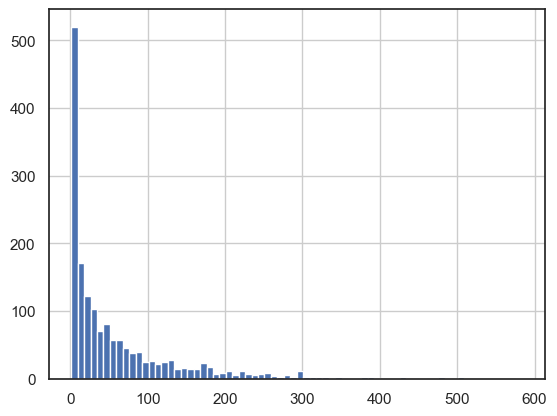

In [53]:
plt.figure
ratings['Num of rating'].hist(bins=70)

<Axes: >

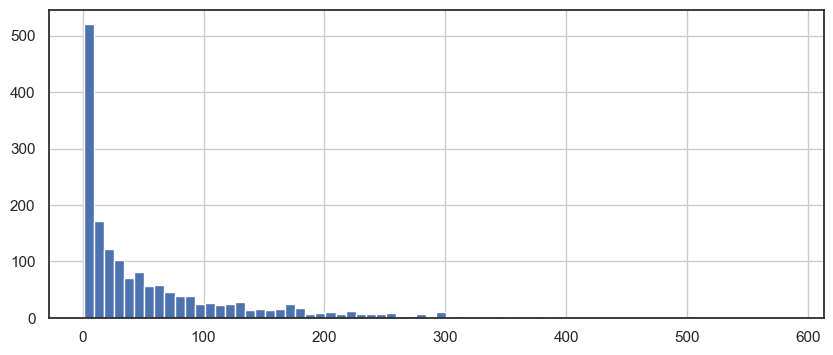

In [54]:
plt.figure(figsize=(10,4))
ratings['Num of rating'].hist(bins=70)

<Axes: >

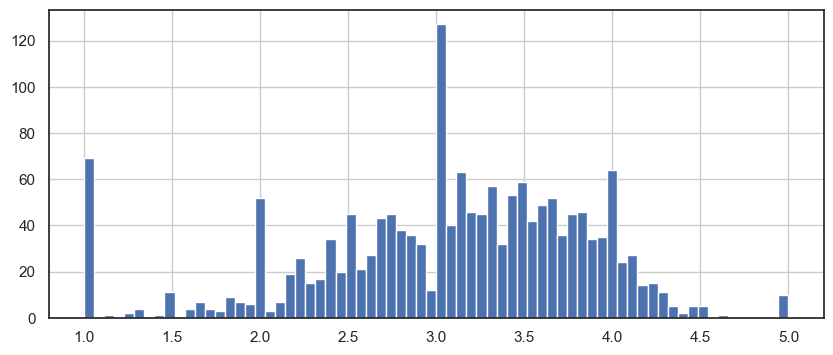

In [67]:
plt.figure(figsize=(10,4))
ratings['Rating'].hist(bins=70)

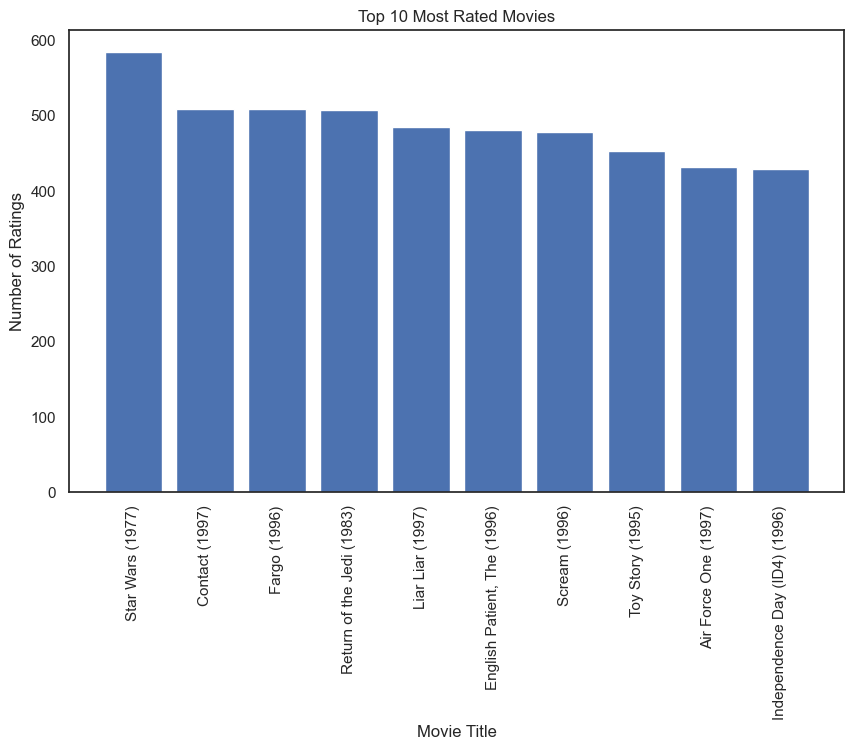

In [65]:
top_movies = ratings.sort_values('Num of rating', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top_movies.index, top_movies['Num of rating'])
plt.xticks(rotation=90)
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")
plt.title("Top 10 Most Rated Movies")
plt.show()

# Top 10 most rated movies sort by Rating

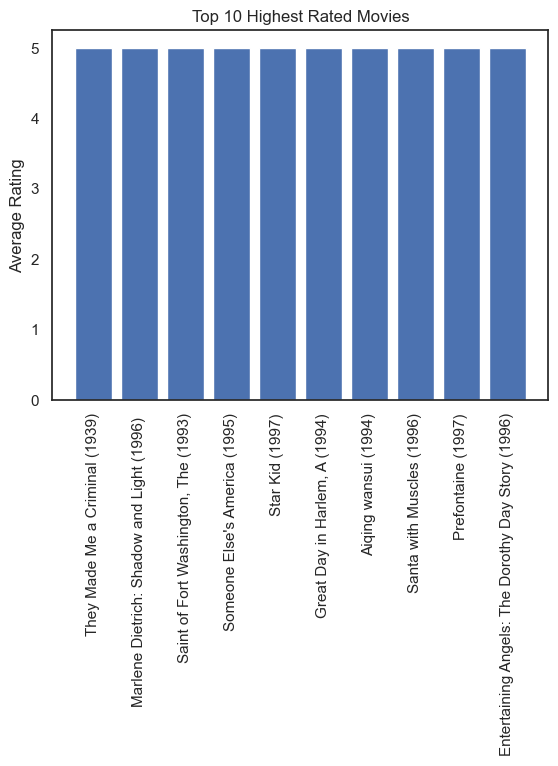

In [66]:
top_rated = ratings.sort_values('Rating', ascending=False).head(10)
plt.figure
plt.bar(top_rated.index, top_rated['Rating'])
plt.xticks(rotation=90)
plt.ylabel("Average Rating")
plt.title("Top 10 Highest Rated Movies")
plt.show()

# Scatter Plot
the best visualization for this is a scatter plot, because you want to compare two numerical variables:

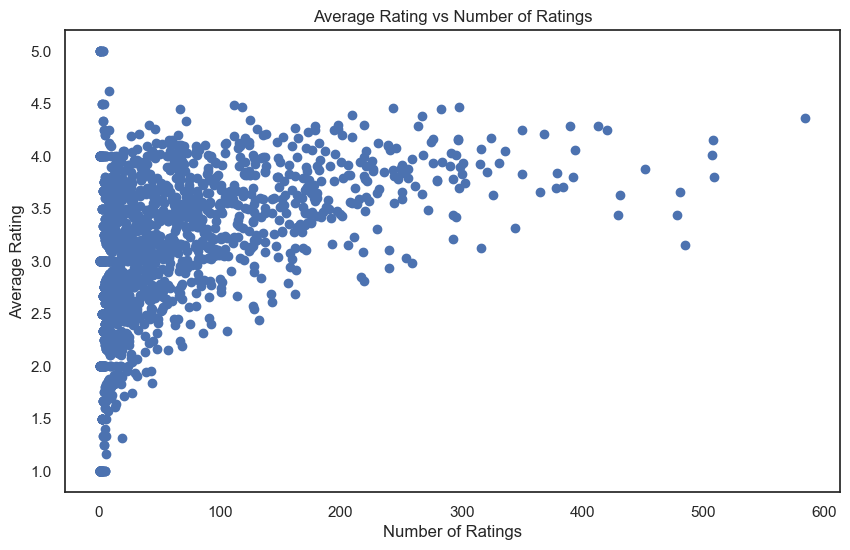

In [63]:
plt.figure(figsize=(10,6))

plt.scatter(ratings['Num of rating'], ratings['Rating'])

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Number of Ratings")

plt.show()

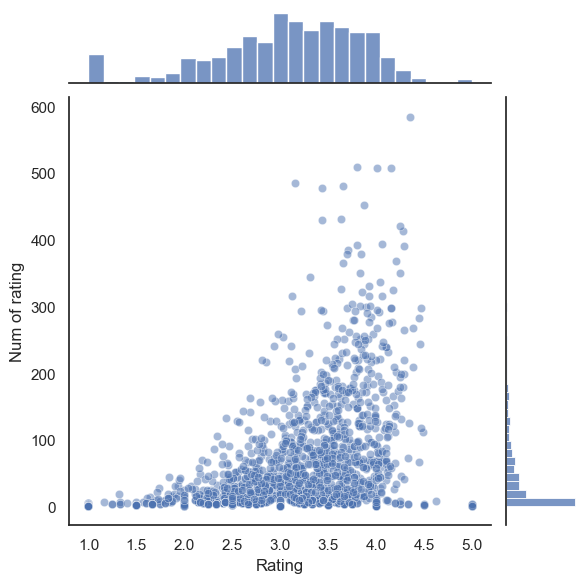

In [72]:
sns.jointplot(x='Rating',y='Num of rating',data=ratings,alpha=0.5)

# Recommending Similar Movies
We use a pivot table to transform the dataset from a long format into a user–movie matrix. Each row represents a user, each column represents a movie, and each cell contains the user's rating. This matrix format is essential for collaborative filtering because it allows us to compare users or movies using similarity measures such as Pearson correlation or cosine similarity.

In [75]:
moviemat= df.pivot_table(index='user_id',columns='title',values='Rating')
moviemat.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
ratings.sort_values('Num of rating',ascending=False).head(10)


,Rating,Num of rating
title,,
Star Wars (1977),4.359589,584
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485
"English Patient, The (1996)",3.656965,481
Scream (1996),3.441423,478
Toy Story (1995),3.878319,452
Air Force One (1997),3.631090,431


In [77]:
ratings.head()

,Rating,Num of rating
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


lets choose 2 movies a starwars a sci fi  movie and liar liar a comedy , Let's grab the user ratings for these two movies

In [87]:
starwars_user_ratings = moviemat['Star Wars (1977)']
liarLiar_user_ratings = moviemat['Liar Liar (1997)']
starwars_user_ratings.head()

user_id
0    5.0
1    5.0
2    5.0
3    NaN
4    5.0
Name: Star Wars (1977), dtype: float64

In [91]:
similar_to_starwars= moviemat.corrwith(starwars_user_ratings)
similar_to_liarliar= moviemat.corrwith(liarLiar_user_ratings)

C:\Users\HEMANGI\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\HEMANGI\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\HEMANGI\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\HEMANGI\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\HEMANGI\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


lets clean this by removing NaN values and using a datafrme instead of series

In [98]:
corr_starwars= pd.DataFrame(similar_to_starwars, columns=['Correlation'])
corr_starwars.dropna(inplace=True)
corr_starwars.head()

,Correlation
title,
'Til There Was You (1997),0.872872
1-900 (1994),-0.645497
101 Dalmatians (1996),0.211132
12 Angry Men (1957),0.184289
187 (1997),0.027398


now if we sort a values by correlation , we should get the most similar movies, however note that we get some results that don't really make sense. This is because there are a lot of movies only watch once by users who also watch star_wars 

In [99]:
corr_starwars.sort_values('Correlation',ascending=False).head(10)

,Correlation
title,
Commandments (1997),1.0
Cosi (1996),1.0
No Escape (1994),1.0
Stripes (1981),1.0
Man of the Year (1995),1.0
Hollow Reed (1996),1.0
"Beans of Egypt, Maine, The (1994)",1.0
"Good Man in Africa, A (1994)",1.0
"Old Lady Who Walked in the Sea, The (Vieille qui marchait dans la mer, La) (1991)",1.0


In [101]:
corr_starwars = corr_starwars.join(ratings['Num of rating'])
corr_starwars.head()

,Correlation,Num of rating
title,,
'Til There Was You (1997),0.872872,9
1-900 (1994),-0.645497,5
101 Dalmatians (1996),0.211132,109
12 Angry Men (1957),0.184289,125
187 (1997),0.027398,41


In [105]:
corr_starwars[corr_starwars['Num of rating']>100].sort_values('Correlation', ascending=False).head()

,Correlation,Num of rating
title,,
Star Wars (1977),1.000000,584
"Empire Strikes Back, The (1980)",0.748353,368
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130


Now the same for the comedy liar liar